In [2]:
from pathlib import Path

dataset_path = Path("../dataset")
raw_data_path = dataset_path / "raw_data"

raw_data_mat = list(raw_data_path.rglob("*.mat"))
raw_data_hea = list(raw_data_path.rglob("*.hea"))

print("===== RAW-DATA =====")
print("MAT files:", len(raw_data_mat))
print("HEA files:", len(raw_data_hea))

===== RAW-DATA =====
MAT files: 8528
HEA files: 8528


In [3]:
import pandas as pd

reference_path = raw_data_path / "REFERENCE.csv"
labels = pd.read_csv(
    reference_path,
    header=None,
    names=["record", "label"]
)

print(labels.head())
print("\nNumber of records:", len(labels))

print("\nClass distribution:")
print(labels["label"].value_counts())

       record label
0  A00/A00001     N
1  A00/A00002     N
2  A00/A00003     N
3  A00/A00004     A
4  A00/A00005     A

Number of records: 8528

Class distribution:
label
N    5076
O    2415
A     758
~     279
Name: count, dtype: int64


In [5]:
first_hea = raw_data_hea[0]

print("File:")
print(first_hea)

print("\nHeader content:\n")

with open(first_hea, "r") as f:
    print(f.read())

File:
..\dataset\raw_data\A00\A00001.hea

Header content:

A00001 1 300 9000 05:05:15 1/05/2000 
A00001.mat 16+24 1000/mV 16 0 -127 0 0 ECG 



In [6]:
import numpy as np
from scipy.io import loadmat

lengths = []

for file in raw_data_mat:
    data = loadmat(file)
    ecg = data["val"]

    signal_length = ecg.shape[1]
    lengths.append(signal_length)

lengths = np.array(lengths)

print("===== ECG LENGTH ANALYSIS =====")

print("Number of ECGs:", len(lengths))
print("Minimum length:", lengths.min(), "samples")
print("Maximum length:", lengths.max(), "samples")
print("Mean length:", round(lengths.mean(), 2), "samples")
print("Median length:", np.median(lengths))
print("Standard deviation:", round(lengths.std(), 2), "samples")

===== ECG LENGTH ANALYSIS =====
Number of ECGs: 8528
Minimum length: 2714 samples
Maximum length: 18286 samples
Mean length: 9749.24 samples
Median length: 9000.0
Standard deviation: 3266.64 samples


In [7]:
sampling_rate = 300

duration_seconds = lengths / sampling_rate

print("===== ECG DURATION =====")

print("Minimum duration:", round(duration_seconds.min(), 2), "seconds")
print("Maximum duration:", round(duration_seconds.max(), 2), "seconds")
print("Mean duration:", round(duration_seconds.mean(), 2), "seconds")
print("Median duration:", round(np.median(duration_seconds), 2), "seconds")

===== ECG DURATION =====
Minimum duration: 9.05 seconds
Maximum duration: 60.95 seconds
Mean duration: 32.5 seconds
Median duration: 30.0 seconds


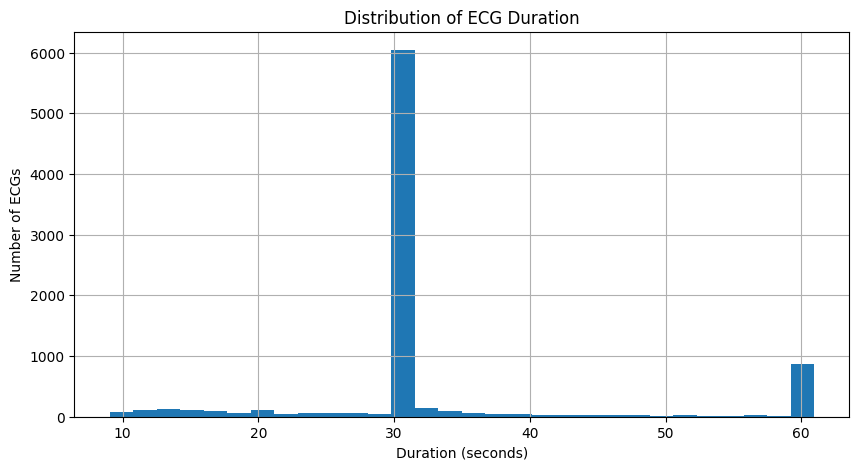

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(duration_seconds, bins=30)

plt.title("Distribution of ECG Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of ECGs")

plt.grid()
plt.show()

In [9]:
exact_30 = np.sum(lengths == 9000)

print("ECGs with exactly 30 seconds:", exact_30)
print("Percentage:", round(exact_30 / len(lengths) * 100, 2), "%")

ECGs with exactly 30 seconds: 5977
Percentage: 70.09 %


In [10]:
labels["length_samples"] = lengths
labels["duration_seconds"] = lengths / 300

print(labels.groupby("label")["duration_seconds"].describe())

        count       mean        std       min    25%   50%   75%        max
label                                                                      
A       758.0  32.344692  12.323600  9.986667  30.00  30.0  30.0  60.206667
N      5076.0  32.111275   9.973795  9.046667  30.00  30.0  30.0  60.953333
O      2415.0  34.295081  11.764910  9.126667  30.00  30.0  30.0  60.860000
~       279.0  24.378769  10.426761  9.360000  14.81  30.0  30.0  60.000000


<Figure size 1000x600 with 0 Axes>

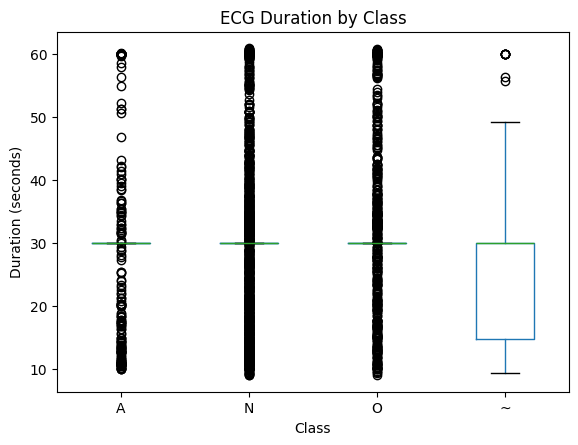

In [11]:
plt.figure(figsize=(10, 6))

labels.boxplot(
    column="duration_seconds",
    by="label"
)

plt.title("ECG Duration by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Duration (seconds)")
plt.grid()

plt.show()